In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data-numeric"
df = pd.read_fwf(url, header=None)
df.columns = [f"f{i}" for i in range(df.shape[1]-1)] + ["target"]
df["target"] = df["target"].map({1: 0, 2: 1})  # 1 = default
df.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f15,f16,f17,f18,f19,f20,f21,f22,f23,target
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,0
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,1
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,0
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,0
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,1


In [3]:
conn = sqlite3.connect(":memory:")
df.to_sql("loans", conn, index=False)

# Example SQL: default rate overall
pd.read_sql("SELECT AVG(target) AS default_rate, COUNT(*) AS n FROM loans", conn)

,default_rate,n
0,0.3,1000


In [4]:
pd.read_sql("""
    SELECT f0 AS feature_bucket,
           COUNT(*) AS n,
           ROUND(AVG(target), 3) AS default_rate
    FROM loans
    GROUP BY f0
    ORDER BY default_rate DESC
""", conn)

,feature_bucket,n,default_rate
0,1,274,0.493
1,2,269,0.390
2,3,63,0.222
3,4,394,0.117


In [5]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_s, y_train)

LogisticRegression(max_iter=1000)

ROC-AUC: 0.820


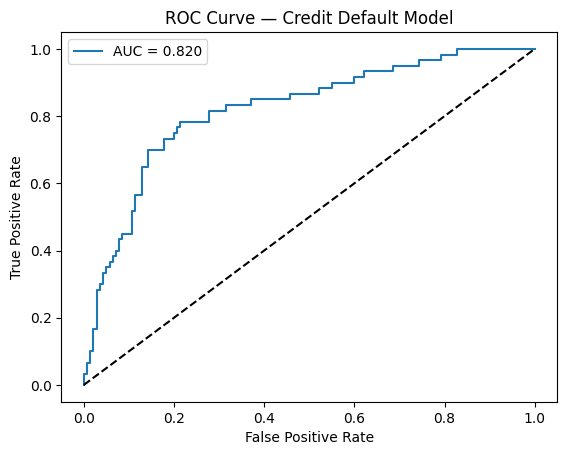

In [6]:
probs = model.predict_proba(X_test_s)[:, 1]
auc = roc_auc_score(y_test, probs)
print(f"ROC-AUC: {auc:.3f}")

fpr, tpr, _ = roc_curve(y_test, probs)
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Credit Default Model"); plt.legend(); plt.show()

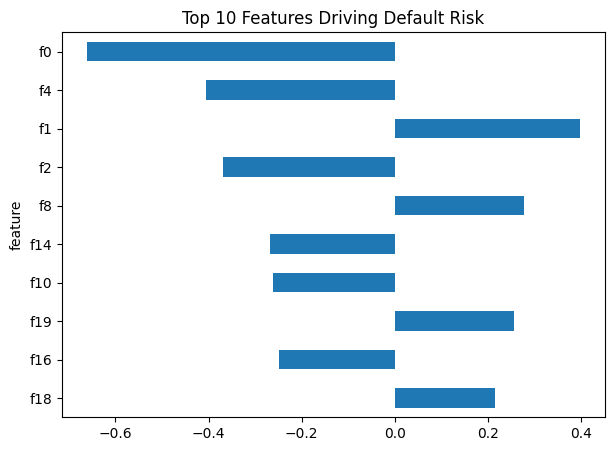

In [7]:
coefs = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False).head(10)

coefs.plot.barh(x="feature", y="coefficient", legend=False, figsize=(7, 5))
plt.title("Top 10 Features Driving Default Risk"); plt.gca().invert_yaxis(); plt.show()